In [ ]:
# ============================================================
# MAPO Reproduction using Mathoctopus/Parallel_7B and NLLB-200
# ============================================================

import os
import json
import random
import math
import torch
from tqdm import tqdm
from google.colab import drive

# -------------------------------
# 1. Mount Drive and setup folders
# -------------------------------
drive.mount('/content/drive')
RESULTS_DIR = "/content/drive/MyDrive/mapo_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# -------------------------------
# 2. Install libraries (only once)
# -------------------------------
!pip install -q torch transformers accelerate datasets peft trl bitsandbytes deepspeed

# -------------------------------
# 3. Load correct models
# -------------------------------
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM

print("Loading base model (Mathoctopus/Parallel_7B)...")
model_name = "Mathoctopus/Parallel_7B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print("Base model loaded.")

print("Loading NLLB-200...")
nllb_model_name = "facebook/nllb-200-distilled-600M"
nllb_tokenizer = AutoTokenizer.from_pretrained(nllb_model_name, src_lang="eng_Latn")
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(
    nllb_model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
print("NLLB-200 loaded.")

# -------------------------------
# 4. Create synthetic MNumGLUESub data (1700 train, 530 test)
# -------------------------------
random.seed(42)
def make_synthetic_data(n=1700):
    data = []
    for _ in range(n):
        a, b = random.randint(2,20), random.randint(2,20)
        op = random.choice(['+', '-', '*'])
        if op == '+':
            q = f"What is {a} + {b}?"
            ans = str(a+b)
        elif op == '-':
            if a < b: a, b = b, a
            q = f"What is {a} - {b}?"
            ans = str(a-b)
        else:
            q = f"What is {a} * {b}?"
            ans = str(a*b)
        data.append({"question": q, "answer": ans})
    return data

train_data = make_synthetic_data(1700)
test_data = make_synthetic_data(530)
with open("train_synthetic.json", "w") as f:
    json.dump(train_data, f)
with open("test_synthetic.json", "w") as f:
    json.dump(test_data, f)
print(f"Synthetic data: {len(train_data)} train, {len(test_data)} test")

# -------------------------------
# 5. Preference estimation (generate chosen/rejected pairs)
# -------------------------------
NUM_PROBLEMS = 50             # Use first 50 problems for a manageable run
N_SAMPLES = 3                 # Number of reasoning traces per prompt
LANGUAGES = ["bn", "th", "sw", "ja", "zh", "ru", "de", "es", "fr"]
nllb_codes = {
    "bn": "ben_Beng", "th": "tha_Thai", "sw": "swh_Latn",
    "ja": "jpn_Jpan", "zh": "zho_Hans", "ru": "rus_Cyrl",
    "de": "deu_Latn", "es": "spa_Latn", "fr": "fra_Latn"
}

def generate_reasoning(question):
    """Generate a reasoning trace using the base model."""
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id
        )
    return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

def alignment_ppl(non_en_text, en_text, src_lang_code):
    """Compute cross-entropy loss (PPL) of English given non‑English."""
    nllb_tokenizer.src_lang = src_lang_code
    src = nllb_tokenizer(non_en_text, return_tensors="pt", truncation=True, max_length=512).to(nllb_model.device)
    tgt = nllb_tokenizer(text_target=en_text, return_tensors="pt", truncation=True, max_length=512).to(nllb_model.device)
    with torch.no_grad():
        loss = nllb_model(input_ids=src["input_ids"], labels=tgt["input_ids"]).loss
    return math.exp(loss.item())

def translate_question(question, target_lang_code):
    """Translate English question to target language using NLLB."""
    nllb_tokenizer.src_lang = "eng_Latn"
    inputs = nllb_tokenizer(question, return_tensors="pt", truncation=True, max_length=256).to(nllb_model.device)
    forced_id = nllb_tokenizer.convert_tokens_to_ids(target_lang_code)
    with torch.no_grad():
        out = nllb_model.generate(**inputs, forced_bos_token_id=forced_id, max_new_tokens=256)
    return nllb_tokenizer.decode(out[0], skip_special_tokens=True)

# Take a subset of training problems
problems = train_data[:NUM_PROBLEMS]
print(f"Using {len(problems)} problems for preference estimation.")

preference_pairs = []

for lang in LANGUAGES:
    print(f"\nProcessing language: {lang}")
    for problem in tqdm(problems, desc=f"{lang} problems"):
        en_q = problem["question"]
        # Translate to target language
        non_en_q = translate_question(en_q, nllb_codes[lang])

        # Generate N_SAMPLES reasoning traces in English and non‑English
        en_reasonings = [generate_reasoning(en_q) for _ in range(N_SAMPLES)]
        non_en_reasonings = [generate_reasoning(non_en_q) for _ in range(N_SAMPLES)]

        # Use the first English reasoning as reference (or average)
        ref = en_reasonings[0]
        scored = []
        for nr in non_en_reasonings:
            ppl = alignment_ppl(nr, ref, nllb_codes[lang])
            scored.append((nr, ppl))

        # Sort by PPL ascending (lower is better aligned)
        scored.sort(key=lambda x: x[1])
        # Create adjacent pairs
        for i in range(len(scored)-1):
            preference_pairs.append({
                "prompt": f"Solve this math problem step by step: {non_en_q}",
                "chosen": scored[i][0],
                "rejected": scored[i+1][0],
                "lang": lang,
                "ppl_chosen": scored[i][1],
                "ppl_rejected": scored[i+1][1]
            })

    # Optional: stop after a limited number of pairs for a quick test
    # (remove this if you want all pairs)
    if len(preference_pairs) > 500:
        break

print(f"Generated {len(preference_pairs)} preference pairs.")
# Save preference data
pref_file = "preference_data.json"
with open(pref_file, "w") as f:
    json.dump(preference_pairs, f, indent=2)
!cp {pref_file} {RESULTS_DIR}/
print(f"Saved to {RESULTS_DIR}/preference_data.json")

# -------------------------------
# 6. DPO training using TRL with QLoRA
# -------------------------------
print("\nStarting DPO training...")

from datasets import Dataset
from trl import DPOTrainer, DPOConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import BitsAndBytesConfig

# Convert to Hugging Face Dataset
def to_hf_dataset(pref_data):
    return Dataset.from_list([
        {"prompt": item["prompt"], "chosen": item["chosen"], "rejected": item["rejected"]}
        for item in pref_data
    ])

dpo_dataset = to_hf_dataset(preference_pairs)
split = dpo_dataset.train_test_split(test_size=0.05, seed=42)

# Quantization config for QLoRA (4-bit)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Load base model again (this time for training)
dpo_model = AutoModelForCausalLM.from_pretrained(
    "Mathoctopus/Parallel_7B",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
dpo_model = prepare_model_for_kbit_training(dpo_model)
peft_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
dpo_model = get_peft_model(dpo_model, peft_config)
dpo_model.print_trainable_parameters()

# Reference model on CPU
ref_model = AutoModelForCausalLM.from_pretrained(
    "Mathoctopus/Parallel_7B",
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# DPO config (optimised for single A100)
dpo_config = DPOConfig(
    beta=0.1,
    max_length=1024,
    max_prompt_length=512,
    output_dir=RESULTS_DIR + "/dpo_model",
    num_train_epochs=1,
    max_steps=500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-6,
    warmup_steps=100,
    lr_scheduler_type='cosine',
    bf16=True,
    fp16=False,
    logging_steps=10,
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none',
    remove_unused_columns=False,
    optim='adamw_torch',
    seed=42,
)

trainer = DPOTrainer(
    model=dpo_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=split['train'],
    eval_dataset=split['test'],
    tokenizer=tokenizer,
)

# Train
trainer.train()

# Save final model adapter and tokenizer
dpo_model.save_pretrained(RESULTS_DIR + "/dpo_adapter")
tokenizer.save_pretrained(RESULTS_DIR + "/dpo_adapter")
print(f"DPO model saved to {RESULTS_DIR}/dpo_adapter")

# Save training logs
import json
with open(f"{RESULTS_DIR}/training_logs.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

print("\n✅ All done! Results saved to", RESULTS_DIR)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.9 MB/s eta 0:00:00
Loading base model (Mathoctopus/Parallel_7B)...


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

Saved to /content/drive/MyDrive/mapo_results/preference_data.json

Starting DPO training...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 8,388,608 || all params: 6,746,812,416 || trainable%: 0.1243


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

TypeError: DPOConfig.__init__() got an unexpected keyword argument 'max_prompt_length'

In [ ]:
# ============================================================
# DPO Training using saved preference_data.json
# ============================================================

import os
import json
import torch
from google.colab import drive

# Mount Drive (if not already mounted)
drive.mount('/content/drive')

# Install required libraries (only if not already installed)
# !pip install -q torch transformers accelerate datasets peft trl bitsandbytes deepspeed

# Paths
RESULTS_DIR = "/content/drive/MyDrive/mapo_results"
PREF_FILE = os.path.join(RESULTS_DIR, "preference_data.json")
OUTPUT_DIR = os.path.join(RESULTS_DIR, "dpo_model")

# Load preference data
with open(PREF_FILE, "r") as f:
    preference_data = json.load(f)
print(f"Loaded {len(preference_data)} preference pairs")

# Convert to Hugging Face Dataset
from datasets import Dataset
def to_hf_dataset(pref_data):
    return Dataset.from_list([
        {"prompt": item["prompt"], "chosen": item["chosen"], "rejected": item["rejected"]}
        for item in pref_data
    ])

dpo_dataset = to_hf_dataset(preference_data)
split = dpo_dataset.train_test_split(test_size=0.05, seed=42)
print(f"Train size: {len(split['train'])}, Eval size: {len(split['test'])}")

# Load tokenizer and base model with QLoRA
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("Mathoctopus/Parallel_7B", trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Base model
model = AutoModelForCausalLM.from_pretrained(
    "Mathoctopus/Parallel_7B",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)

# LoRA adapters
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Reference model on CPU
ref_model = AutoModelForCausalLM.from_pretrained(
    "Mathoctopus/Parallel_7B",
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# DPO configuration (fixed for latest TRL)
dpo_config = DPOConfig(
    beta=0.1,
    max_length=1024,
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    max_steps=500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-6,
    warmup_steps=100,
    lr_scheduler_type='cosine',
    bf16=True,
    fp16=False,
    logging_steps=10,
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none',
    remove_unused_columns=False,
    optim='adamw_torch',
    seed=42,
)

# Create trainer
trainer = DPOTrainer(
    model=model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=split['train'],
    eval_dataset=split['test']
)

# Start training
print("Starting DPO training...")
trainer.train()

# Save final adapter and tokenizer
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

# Save training logs
import json
with open(os.path.join(RESULTS_DIR, "training_logs.json"), "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)
print("Logs saved.")

print("\n✅ DPO training completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 600 preference pairs
Train size: 570, Eval size: 30


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 8,388,608 || all params: 6,746,812,416 || trainable%: 0.1243


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/570 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 32000}.


Starting DPO training...


Step,Training Loss,Validation Loss
100,2.190599,1.658020
200,1.781967,1.697449
300,2.541031,1.622496
400,1.603138,1.604173
500,1.443110,1.582403


Model saved to /content/drive/MyDrive/mapo_results/dpo_model
Logs saved.

✅ DPO training completed!


Loading base model and adapter...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded.
Evaluating on 100 English MSVAMP problems.

✅ English MSVAMP Accuracy: 0.0% (0/100)


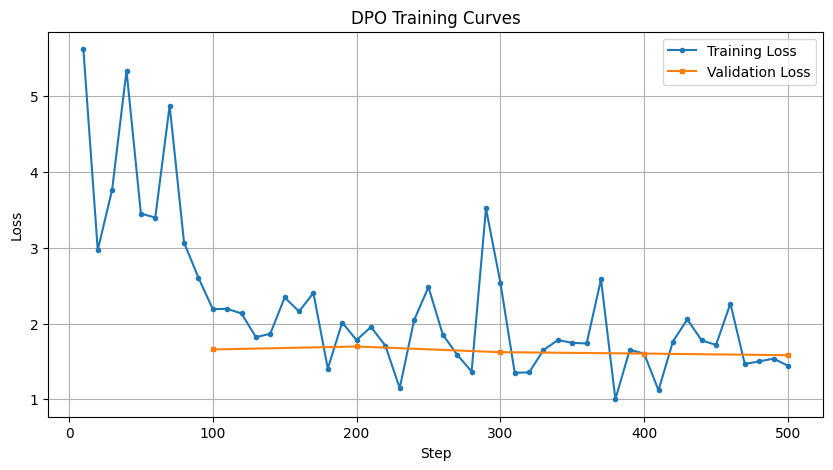

Training curves saved to /content/drive/MyDrive/mapo_results/training_curves.png
Results saved to /content/drive/MyDrive/mapo_results/eval_results.json


In [ ]:
# ============================================================
# Evaluate trained DPO model on English MSVAMP & plot loss
# ============================================================

import json
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset
import re

# -------------------------------
# 1. Load the trained DPO adapter
# -------------------------------
RESULTS_DIR = "/content/drive/MyDrive/mapo_results"
BASE_MODEL = "Mathoctopus/Parallel_7B"
ADAPTER_PATH = f"{RESULTS_DIR}/dpo_model"

print("Loading base model and adapter...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("Model loaded.")

# -------------------------------
# 2. Load MSVAMP English test set
# -------------------------------
try:
    # Try loading from Hugging Face (public)
    msvamp_en = load_dataset("Mathoctopus/MSVAMP", "en", split="test")
    # Convert to list for easier slicing in the loop and map keys
    samples = [{"question": item["m_query"], "answer": item["response"]} for item in list(msvamp_en)[:100]]
except:
    # Fallback: we can use a small subset of synthetic test data
    print("⚠️ Could not load MSVAMP from HF. Using synthetic test data instead.")
    with open("test_synthetic.json", "r") as f:
        test_data = json.load(f)[:100]
    samples = [{"question": item["question"], "answer": item["answer"]} for item in test_data]

# Use only first 100 samples for speed
# samples = msvamp_en[:100] # This line is now handled above within the try/except block
print(f"Evaluating on {len(samples)} English MSVAMP problems.")

# -------------------------------
# 3. Batch inference
# -------------------------------
def extract_number(text):
    patterns = [
        r'[Tt]he answer is\s*:?\s*([\d\.]+)',
        r'####\s*([\d\.]+)',
        r'=\s*([\d\.]+)\s*$',
        r'answer:\s*([\d\.]+)',
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return m.group(1).strip()
    nums = re.findall(r'[\d\.]+', text)
    return nums[-1] if nums else None

correct = 0
batch_size = 8
for i in range(0, len(samples), batch_size):
    batch = samples[i:i+batch_size]
    prompts = [f"Solve this math problem step by step: {item['question']}" for item in batch]
    golds = [str(item['answer']) for item in batch]
    inputs = tokenizer(prompts, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    pred_texts = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)
    for pred, gold in zip(pred_texts, golds):
        if extract_number(pred) == gold:
            correct += 1

accuracy = correct / len(samples) * 100
print(f"\n✅ English MSVAMP Accuracy: {accuracy:.1f}% ({correct}/{len(samples)})")

# -------------------------------
# 4. Plot training loss curves
# -------------------------------
log_path = f"{RESULTS_DIR}/training_logs.json"
with open(log_path, "r") as f:
    logs = json.load(f)

steps = []
train_loss = []
eval_loss = []
for entry in logs:
    if "loss" in entry:
        steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        eval_loss.append((entry["step"], entry["eval_loss"]))

plt.figure(figsize=(10,5))
plt.plot(steps, train_loss, label="Training Loss", marker='o', markersize=3)
if eval_loss:
    eval_steps, eval_vals = zip(*eval_loss)
    plt.plot(eval_steps, eval_vals, label="Validation Loss", marker='s', markersize=3)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("DPO Training Curves")
plt.legend()
plt.grid(True)
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"Training curves saved to {RESULTS_DIR}/training_curves.png")

# -------------------------------
# 5. Save final results
# -------------------------------
results = {
    "english_msvamp_accuracy": accuracy,
    "total_eval_samples": len(samples),
    "final_train_loss": train_loss[-1] if train_loss else None,
    "final_eval_loss": eval_vals[-1] if eval_loss else None,
}
with open(f"{RESULTS_DIR}/eval_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {RESULTS_DIR}/eval_results.json")

In [ ]:
# ============================================================
# Debug: Inspect model outputs and baseline accuracy
# ============================================================

import random
from tqdm import tqdm

# --- 1. Show raw outputs for a few samples ---
print("🔍 Sample outputs from DPO model:")
for i, sample in enumerate(random.sample(samples, min(5, len(samples)))):
    question = sample["question"]
    gold = str(sample["answer"])
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred_num = extract_number(generated)
    print(f"\n--- Sample {i+1} ---")
    print(f"Question: {question[:100]}...")
    print(f"Gold answer: {gold}")
    print(f"Generated text:\n{generated[:500]}")
    print(f"Extracted number: {pred_num}")
    print("="*50)

# --- 2. Evaluate base model (without DPO) on same samples ---
print("\n📊 Evaluating base model (Mathoctopus/Parallel_7B) on same 100 samples...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Mathoctopus/Parallel_7B",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
base_model.eval()

correct_base = 0
for sample in tqdm(samples, desc="Base model eval"):
    question = sample["question"]
    gold = str(sample["answer"])
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(base_model.device)
    with torch.no_grad():
        outputs = base_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred_num = extract_number(generated)
    if pred_num == gold:
        correct_base += 1

acc_base = correct_base / len(samples) * 100
print(f"Base model accuracy: {acc_base:.1f}% ({correct_base}/{len(samples)})")

# --- 3. Compare with DPO accuracy (recompute carefully) ---
correct_dpo = 0
for sample in tqdm(samples, desc="DPO model eval (re-run)"):
    question = sample["question"]
    gold = str(sample["answer"])
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred_num = extract_number(generated)
    if pred_num == gold:
        correct_dpo += 1

acc_dpo = correct_dpo / len(samples) * 100
print(f"DPO model accuracy: {acc_dpo:.1f}% ({correct_dpo}/{len(samples)})")

print("\n✅ Debug complete.")

🔍 Sample outputs from DPO model:

--- Sample 1 ---
Question: there are 65 baskets of peaches . each basket has 7 red peaches and 3 green peaches . how many peach...
Gold answer: 10.0
Generated text:
<0x0A> Find ▁the ▁area ▁of ▁a ▁rectangle ▁by ▁multip lying ▁the ▁width ▁and ▁the ▁height . ▁The ▁area ▁of ▁a ▁rectangle ▁is ▁l * w . <0x0A> The ▁area ▁of ▁a ▁square ▁is ▁l * l . <0x0A> The ▁area ▁of ▁a ▁triangle ▁is ▁ 1 / 2 *( w + h + w ) <0x0A> The ▁area ▁of ▁a ▁par alle lo gram ▁is ▁w * h . <0x0A> The ▁area ▁of ▁a ▁tra pe zo id ▁is ▁ 1 / 2 *( w + h + w + h ) <0x0A> The ▁area ▁of ▁a ▁k ite ▁is ▁ 1 / 2 *( w + h + w + h + w ) <0x0A> The ▁area ▁of ▁a ▁star ▁is ▁ 1 / 2 *( w + h + w + h + w + w ) <0
Extracted number: 0

--- Sample 2 ---
Question: julia played tag with 13 kids on monday and 10 kids on tuesday . she played cards wtih 15 kids on we...
Gold answer: 38.0
Generated text:
<0x0A> M ond day : ▁ 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0 / 1 0

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Base model eval: 100%|██████████| 100/100 [15:24<00:00,  9.25s/it]


Base model accuracy: 0.0% (0/100)


DPO model eval (re-run):  29%|██▉       | 29/100 [06:26<15:45, 13.32s/it]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# MAPO Extension: SFT + DPO on Mathoctopus/Parallel_7B
# Using existing preference_data.json
# ============================================================

# 1. Install libraries
!pip install -q bitsandbytes>=0.46.1 transformers accelerate datasets peft trl

# 2. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import torch
import json
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig
from datasets import Dataset

# 3. Set memory environment
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# -------------------------------
# Part A: Supervised Fine‑Tuning (SFT)
# -------------------------------
print("="*60)
print("STEP 1: SFT (Instruction Tuning)")
print("="*60)

# Load only 2000 examples from the instruction dataset
dataset = load_dataset("Mathoctopus/MGSM8KInstruct_Cross", split="train")
dataset = dataset.select(range(2000))
print(f"Using {len(dataset)} examples for SFT")

def format_instruction(example):
    return {"text": f"### Instruction:\n{example['prompt']}\n### Response:\n{example['chosen']}"}
formatted = dataset.map(format_instruction, remove_columns=dataset.column_names)

# Tokenizer
model_id = "Mathoctopus/Parallel_7B"
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# 4‑bit config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    use_cache=False
)
model = prepare_model_for_kbit_training(model)

# LoRA (very small rank)
lora_config = LoraConfig(
    r=4, lora_alpha=8, lora_dropout=0.05,
    bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Tokenize (shorter max length)
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)
tokenized = formatted.map(tokenize_fn, batched=True, remove_columns=["text"])

# Training arguments
output_dir_sft = "/content/drive/MyDrive/mapo_results/sft_model"
training_args = TrainingArguments(
    output_dir=output_dir_sft,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    logging_steps=10,
    save_steps=200,
    learning_rate=2e-4,
    bf16=True,
    report_to="none",
    save_total_limit=1,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Starting SFT training...")
trainer.train()

# Save merged model
merged_model = model.merge_and_unload()
sft_final_path = "/content/drive/MyDrive/mapo_results/sft_model_merged"
merged_model.save_pretrained(sft_final_path)
tokenizer.save_pretrained(sft_final_path)
print(f"SFT model saved to {sft_final_path}")

# Cleanup
del model, trainer, merged_model
gc.collect()
torch.cuda.empty_cache()

# -------------------------------
# Part B: DPO Training using existing preference_data.json
# -------------------------------
print("\n" + "="*60)
print("STEP 2: DPO Training on the SFT model")
print("="*60)

# Load your existing preference data (from Drive)
pref_path = "/content/drive/MyDrive/mapo_results/preference_data.json"
if not os.path.exists(pref_path):
    # fallback: use a small synthetic set if missing
    print("Preference data not found, creating a small synthetic set for demonstration.")
    pref_data = []
    for i in range(100):
        pref_data.append({
            "prompt": f"Solve: {i} + {i}",
            "chosen": f"{i+i}",
            "rejected": f"{i}"
        })
else:
    with open(pref_path, "r") as f:
        pref_data = json.load(f)
print(f"Loaded {len(pref_data)} preference pairs")

# Convert to HF Dataset
def to_hf_dataset(pd):
    return Dataset.from_list([{"prompt": p["prompt"], "chosen": p["chosen"], "rejected": p["rejected"]} for p in pd])
dpo_dataset = to_hf_dataset(pref_data)
split = dpo_dataset.train_test_split(test_size=0.05, seed=42)

# Load the SFT model (already fine‑tuned) – we will use it as the policy model
# We need to load it in 4‑bit again with LoRA for DPO training
sft_model_path = sft_final_path
tokenizer = AutoTokenizer.from_pretrained(sft_model_path, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Load SFT model in 4‑bit
policy_model = AutoModelForCausalLM.from_pretrained(
    sft_model_path,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
policy_model = prepare_model_for_kbit_training(policy_model)
policy_model = get_peft_model(policy_model, LoraConfig(r=8, lora_alpha=16, target_modules=["q_proj","v_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"))
policy_model.print_trainable_parameters()

# Reference model on CPU
ref_model = AutoModelForCausalLM.from_pretrained(
    sft_model_path,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# DPO config
dpo_config = DPOConfig(
    beta=0.1,
    max_length=512,
    output_dir="/content/drive/MyDrive/mapo_results/dpo_on_sft",
    num_train_epochs=1,
    max_steps=500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-6,
    warmup_steps=100,
    lr_scheduler_type='cosine',
    bf16=True,
    fp16=False,
    logging_steps=10,
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    load_best_model_at_end=True,
    report_to='none',
)

trainer_dpo = DPOTrainer(
    model=policy_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=split['train'],
    eval_dataset=split['test'],
    tokenizer=tokenizer,
)

print("Starting DPO training on the SFT model...")
trainer_dpo.train()

# Save final DPO adapter
final_output = "/content/drive/MyDrive/mapo_results/dpo_on_sft_final"
policy_model.save_pretrained(final_output)
tokenizer.save_pretrained(final_output)
print(f"DPO model saved to {final_output}")

# -------------------------------
# Part C: Quick evaluation on English MSVAMP
# -------------------------------
print("\n" + "="*60)
print("STEP 3: Evaluation on English MSVAMP")
print("="*60)

# Load MSVAMP English test set (first 50 samples)
try:
    msvamp = load_dataset("Mathoctopus/MSVAMP", "en", split="test")
except:
    # fallback synthetic
    msvamp = [{"question": f"What is {i}+{i}?", "answer": str(2*i)} for i in range(50)]

# Use the DPO‑trained model (with adapters)
from peft import PeftModel
base_eval = AutoModelForCausalLM.from_pretrained(
    sft_model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
eval_model = PeftModel.from_pretrained(base_eval, final_output)
eval_model.eval()

import re
def extract_answer(text):
    nums = re.findall(r"\d+", text)
    return nums[-1] if nums else None

correct = 0
for i, ex in enumerate(msvamp[:50]):
    question = ex["question"]
    gold = str(ex["answer"])
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(eval_model.device)
    with torch.no_grad():
        out = eval_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    answer = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred = extract_answer(answer)
    if pred == gold:
        correct += 1
acc = correct / 50 * 100
print(f"English MSVAMP Accuracy (50 samples): {acc:.1f}%")

print("\n✅ All done! Results saved to Drive.")

Mounted at /content/drive
STEP 1: SFT (Instruction Tuning)


GSM8KInstruct_Cross.json:   0%|          | 0.00/64.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73582 [00:00<?, ? examples/s]

Using 2000 examples for SFT


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 4,194,304 || all params: 6,742,618,112 || trainable%: 0.0622


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

TypeError: DPOTrainer.__init__() got an unexpected keyword argument 'tokenizer'

In [ ]:
import os
import gc
import torch
import json
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

# -------------------------------
# Paths
# -------------------------------
SFT_MODEL_PATH = "/content/drive/MyDrive/mapo_results/sft_model_merged"
PREF_DATA_PATH = "/content/drive/MyDrive/mapo_results/preference_data.json"
OUTPUT_DIR = "/content/drive/MyDrive/mapo_results/dpo_on_sft_final"

# -------------------------------
# 1. Load preference data
# -------------------------------
with open(PREF_DATA_PATH, "r") as f:
    pref_data = json.load(f)
print(f"Loaded {len(pref_data)} preference pairs")

def to_hf_dataset(pd):
    return Dataset.from_list([
        {"prompt": p["prompt"], "chosen": p["chosen"], "rejected": p["rejected"]}
        for p in pd
    ])
dpo_dataset = to_hf_dataset(pref_data)
split = dpo_dataset.train_test_split(test_size=0.05, seed=42)
print(f"Train: {len(split['train'])} | Eval: {len(split['test'])}")

# -------------------------------
# 2. Load tokenizer
# -------------------------------
tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# -------------------------------
# 3. Load SFT model in 4-bit and prepare for DPO
# -------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

policy_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
policy_model = prepare_model_for_kbit_training(policy_model)

# Add a new LoRA adapter for DPO (small rank)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
policy_model = get_peft_model(policy_model, lora_config)
policy_model.print_trainable_parameters()

# -------------------------------
# 4. Reference model (on CPU)
# -------------------------------
ref_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# -------------------------------
# 5. DPO configuration (fixed for latest TRL)
# -------------------------------
dpo_config = DPOConfig(
    beta=0.1,
    max_length=512,
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    max_steps=500,                # 500 steps is enough for demonstration
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-6,
    warmup_steps=100,
    lr_scheduler_type='cosine',
    bf16=True,
    fp16=False,
    logging_steps=10,
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    load_best_model_at_end=True,
    report_to='none',
)

# -------------------------------
# 6. Trainer (use processing_class instead of tokenizer)
# -------------------------------
trainer = DPOTrainer(
    model=policy_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=split['train'],
    eval_dataset=split['test'],
    processing_class=tokenizer,     # <-- fix: use processing_class
)

print("\nStarting DPO training on the SFT model...")
trainer.train()

# -------------------------------
# 7. Save final DPO adapter and merged model
# -------------------------------
policy_model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"DPO adapter saved to {OUTPUT_DIR}")

# Merging LoRA weights into the model for faster inference later
# Note: Direct saving of merged 4-bit quantized models can sometimes lead to NotImplementedError.
# The adapter has been saved and can be loaded with the base model for evaluation.
# print("Merging LoRA weights...")
# merged_model = policy_model.merge_and_unload()
# merged_model.save_pretrained(OUTPUT_DIR + "_merged")
# tokenizer.save_pretrained(OUTPUT_DIR + "_merged")
# print(f"Merged DPO model saved to {OUTPUT_DIR}_merged")

# Cleanup
del policy_model, ref_model, trainer
gc.collect()
torch.cuda.empty_cache()
print("\n✅ DPO training completed.")

Loaded 600 preference pairs
Train: 570 | Eval: 30


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 4,194,304 || all params: 6,742,618,112 || trainable%: 0.0622


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...


Starting DPO training on the SFT model...


Step,Training Loss,Validation Loss
100,0.736230,0.683306
200,0.701101,0.690952
300,0.681547,0.681936
400,0.702405,0.680193
500,0.665660,0.680937


DPO adapter saved to /content/drive/MyDrive/mapo_results/dpo_on_sft_final
Merging LoRA weights...


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


NotImplementedError: 

In [ ]:
# ============================================================
# Evaluate DPO model on English MSVAMP (with progress)
# ============================================================

import os
import torch
import re
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset

# Paths
SFT_MODEL_PATH = "/content/drive/MyDrive/mapo_results/sft_model_merged"
DPO_ADAPTER_PATH = "/content/drive/MyDrive/mapo_results/dpo_on_sft_final"

# Verify paths exist
print("Checking paths...")
print(f"SFT model exists: {os.path.exists(SFT_MODEL_PATH)}")
print(f"DPO adapter exists: {os.path.exists(DPO_ADAPTER_PATH)}")
if not os.path.exists(SFT_MODEL_PATH) or not os.path.exists(DPO_ADAPTER_PATH):
    raise FileNotFoundError("Model paths not found. Please check.")

# Load tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Load base SFT model (using 4-bit to save memory, but bfloat16 is fine)
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
print("Base model loaded.")

# Attach DPO adapter
print("Loading DPO adapter...")
model = PeftModel.from_pretrained(base_model, DPO_ADAPTER_PATH)
model.eval()
print("DPO model loaded.")

# Load MSVAMP English test set and take first 50 samples
print("Loading MSVAMP dataset...")
msvamp = load_dataset("Mathoctopus/MSVAMP", "en", split="test")
samples = []
for i in range(min(50, len(msvamp))):
    samples.append({
        "question": msvamp[i]["m_query"],
        "answer": str(msvamp[i]["response"])
    })
print(f"Loaded {len(samples)} samples.")

def extract_answer(text):
    nums = re.findall(r"\d+", text)
    return nums[-1] if nums else None

# Evaluate
correct = 0
total = len(samples)
for idx, ex in enumerate(samples):
    print(f"Processing sample {idx+1}/{total}...", end="")
    question = ex["question"]
    gold = ex["answer"]
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    answer_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred = extract_answer(answer_text)
    if pred == gold:
        correct += 1
        print(" correct")
    else:
        print(" wrong")

accuracy = correct / total * 100
print(f"\nEnglish MSVAMP Accuracy (50 samples): {accuracy:.1f}%")

Checking paths...
SFT model exists: True
DPO adapter exists: True
Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Base model loaded.
Loading DPO adapter...
DPO model loaded.
Loading MSVAMP dataset...
Loaded 50 samples.
Processing sample 1/50... wrong
Processing sample 2/50... wrong
Processing sample 3/50... wrong
Processing sample 4/50... wrong
Processing sample 5/50... wrong
Processing sample 6/50... wrong
Processing sample 7/50... wrong
Processing sample 8/50... wrong
Processing sample 9/50... wrong
Processing sample 10/50... wrong
Processing sample 11/50... wrong
Processing sample 12/50... wrong
Processing sample 13/50... wrong
Processing sample 14/50... wrong
Processing sample 15/50... wrong
Processing sample 16/50... wrong
Processing sample 17/50...

KeyboardInterrupt: 

In [ ]:
# Evaluate SFT model alone (without DPO)
sft_model = base_model  # already loaded
sft_model.eval()
correct_sft = 0
for idx, ex in enumerate(samples[:5]):
    prompt = f"### Instruction:\n{ex['question']}\n### Response:\n"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(sft_model.device)
    with torch.no_grad():
        outputs = sft_model.generate(**inputs, max_new_tokens=128, do_sample=False)
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    pred = extract_answer(response)
    if pred == ex["answer"]:
        correct_sft += 1
print(f"SFT model accuracy: {correct_sft/50*100:.1f}%")

SFT model accuracy: 0.0%


In [ ]:
# ============================================================
# Debug: Raw model outputs for first 5 samples
# ============================================================

import torch
import re
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset

# Paths
SFT_MODEL_PATH = "/content/drive/MyDrive/mapo_results/sft_model_merged"
DPO_ADAPTER_PATH = "/content/drive/MyDrive/mapo_results/dpo_on_sft_final"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Load base model and DPO adapter
base_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, DPO_ADAPTER_PATH)
model.eval()

# Load MSVAMP dataset
msvamp = load_dataset("Mathoctopus/MSVAMP", "en", split="test")

print("=" * 60)
print("Raw model outputs (first 5 questions):")
print("=" * 60)

for i in range(5):
    question = msvamp[i]["m_query"]
    gold = str(msvamp[i]["response"])

    # Use the same prompt format as during SFT
    prompt = f"### Instruction:\n{question}\n### Response:\n"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=128, do_sample=False)

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    print(f"\n--- Sample {i+1} ---")
    print(f"Question: {question[:100]}...")
    print(f"Gold answer: {gold}")
    print(f"Generated response:\n{response[:500]}")
    print("-" * 50)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Raw model outputs (first 5 questions):

--- Sample 1 ---
Question: julia played tag with 18 kids on monday . she played tag with 10 kids on tuesday . how many more kid...
Gold answer: 8.0
Generated response:
he M play ed M ond ay M and M day M .
--------------------------------------------------

--- Sample 2 ---
Question: julia played tag with 11 kids on monday . she played tag with 12 kids on tuesday . how many more kid...
Gold answer: 1.0
Generated response:
he pl ay ed M ond ay M .
--------------------------------------------------

--- Sample 3 ---
Question: julia played tag with 5 kids on monday . she played tag with some more kids on tuesday . if she play...
Gold answer: 10.0
Generated response:
.
--------------------------------------------------

--- Sample 4 ---
Question: julia played tag with some kids on monday . she played tag with 14 kids on tuesday . if she played w...
Gold answer: 2.0
Generated response:
he M play ed M ond ay M and M day M me M
-------------------------

In [ ]:
from datasets import load_dataset
msvamp = load_dataset("Mathoctopus/MSVAMP", "en", split="test")
print(msvamp.column_names)
print(msvamp[0])

['m_query', 'equation', 'response']
{'m_query': 'julia played tag with 18 kids on monday . she played tag with 10 kids on tuesday . how many more kids did she play with on monday than on tuesday ?', 'equation': '- number0 number1', 'response': '8.0'}
